In [1]:
import numpy as np
species = np.fromfile("/home/posner/NSphere/data/all_particle_species_100000_10001_20.dat", dtype=np.int32)
#species = species.reshape(n_snapshots, npts)  # rows = time, cols = particle orig_id

print(species.shape)
print(species[:10])

(10100000,)
[0 0 0 0 0 1 0 0 0 0]


(101, 100000)
(101, 100000)
(101, 100000)


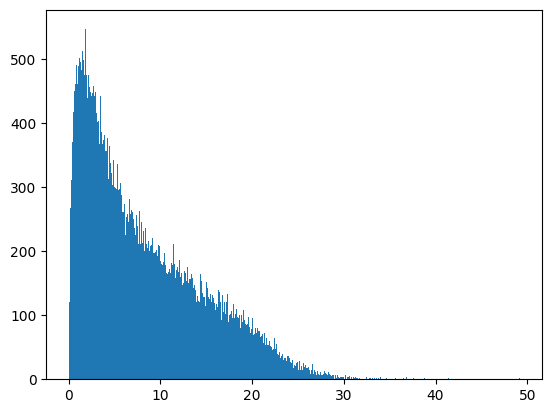

In [2]:
import matplotlib.pyplot as plt
n_snapshots = 100+1
npts = 100000

dt = np.dtype([('rank','i4'),('R','f4'),('Vrad','f4'),('L','f4'),('species','i4')])
data = np.fromfile("/home/posner/NSphere/data/all_particle_data_100000_10001_20.dat",dtype = dt).reshape(n_snapshots, npts)

print(data.shape)
rad = data["R"]
species = data["species"]
Vrad = data["Vrad"]
print(Vrad.shape)
print(species.shape)


max_range = 30
#bin_edges = np.arange(0, max_range, 0.05)


plt.hist(rad[0], bins = 1000);
plt.show();


(101, 100000)
(101, 100000)


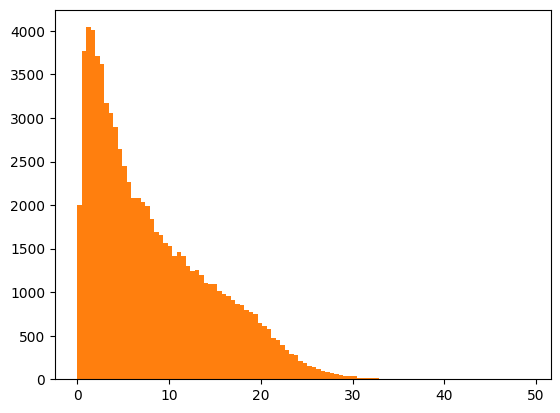

In [3]:
rad_dm = np.where(species == 0, rad, np.nan)
rad_bar = np.where(species == 1, rad, np.nan)

print(rad_dm.shape)
print(rad_bar.shape)

plt.hist(rad_bar[0], bins = 100)
plt.hist(rad_dm[0], bins = 100)


plt.show();


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.ndimage import gaussian_filter1d
from IPython.display import HTML


file_path = "/home/posner/NSphere/data/all_particle_data_100000_10001_20.dat"

max_range = 30
bin_edges = np.arange(0, max_range, 0.05)
sigma = 2
time_steps = range(0, rad.shape[0], 1)

#smoothing for dm
all_smoothed_counts_dm = []
all_bins_dm = np.array([])
for i in range(rad_dm.shape[0]):
    counts, bins = np.histogram(rad_dm[i], bins=bin_edges)
    smoothed_counts = gaussian_filter1d(counts, sigma=sigma)
    all_smoothed_counts_dm.append(smoothed_counts)

    bins_centered = (bins[:-1] + bins[1:]) / 2
    np.append(all_bins_dm, bins_centered)
    
all_smoothed_counts_dm = np.array(all_smoothed_counts_dm)
all_bins_dm = np.array(all_bins_dm)

#smoothing for bar
all_smoothed_counts_bar = []
all_bins_bar = np.array([])
for i in range(rad_bar.shape[0]):
    counts, bins = np.histogram(rad_bar[i], bins=bin_edges)
    smoothed_counts = gaussian_filter1d(counts, sigma=sigma)
    all_smoothed_counts_bar.append(smoothed_counts)

    bins_centered = (bins[:-1] + bins[1:]) / 2
    np.append(all_bins_bar, bins_centered)
    
all_smoothed_counts_bar = np.array(all_smoothed_counts_bar)
all_bins_bar = np.array(all_bins_bar)



bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create animation
fig, ax = plt.subplots()
line_dm, = ax.plot(bin_centers, all_smoothed_counts_dm[0], color="b", label = "Dark Matter")
line_bar, = ax.plot(bin_centers, all_smoothed_counts_bar[0], color="r", label = "Baryonic Matter")
ax.legend()

ax.set_xlim(0, max_range)      # Lower limit is > 0
# Compute the global maximum of all frames
global_max = np.max(np.stack((all_smoothed_counts_dm,all_smoothed_counts_bar)))
# Set the y-axis limit to be 5% higher than this maximum for better visualization
ax.set_ylim(0, global_max * 1.05)

ax.set_xlabel("Radius")
ax.set_ylabel("Number of Particles")
ax.set_title("Evolution of Particle Distribution")

def update(frame):
    line_dm.set_ydata(all_smoothed_counts_dm[frame])  # Update the y-data for the line
    line_bar.set_ydata(all_smoothed_counts_bar[frame])  # Update the y-data for the line
    ax.set_title(f"Time Step: {time_steps[frame]}")
    return line_dm, line_bar

ani = FuncAnimation(fig, update, frames=len(time_steps), repeat=True, interval=200)

# Uncomment this line to show a static plot of the initial conditions
#plt.show()

plt.close(fig)

# Uncomment this line to save the animation as a GIF
#ani.save("../results/nsphere_density_example.gif", writer="pillow", fps=10)

HTML(ani.to_jshtml())

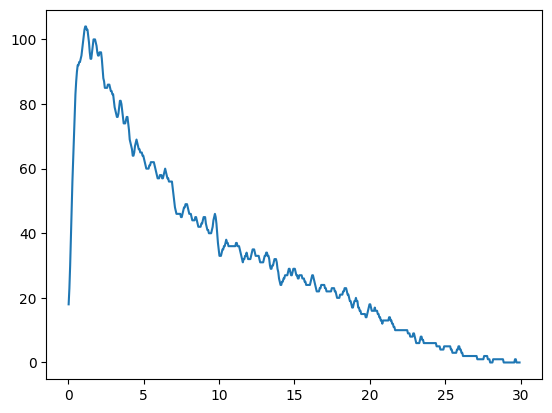

In [5]:
plt.plot(bin_centers, all_smoothed_counts_bar[0])

1.2575432


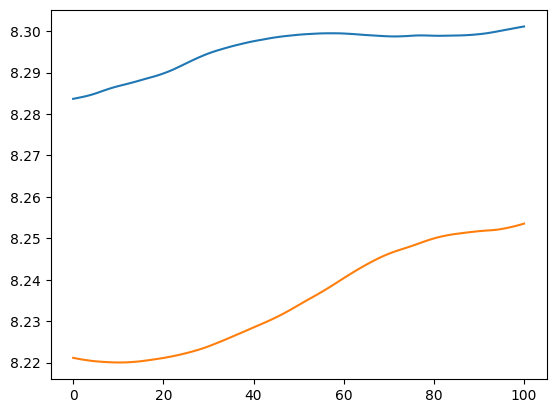

In [6]:
mean_rad_bar = np.nanmean(rad_bar, axis = 1)
mean_rad_dm = np.nanmean(rad_dm, axis = 1)

print(rad_dm[10,2])
plt.plot(time_steps,mean_rad_bar)
plt.plot(time_steps,mean_rad_dm)


1.2575432


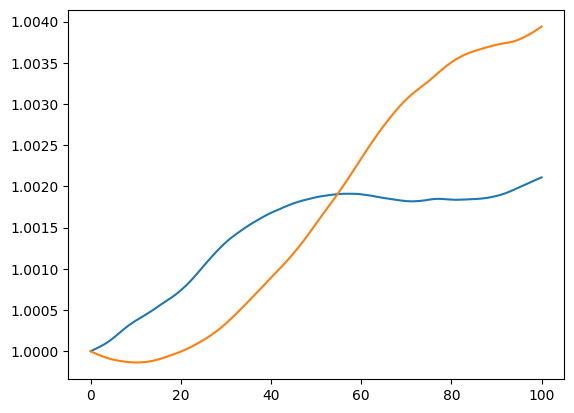

In [7]:
mean_rad_bar_norm = mean_rad_bar / mean_rad_bar[0]
mean_rad_dm_norm = mean_rad_dm / mean_rad_dm[0]

print(rad_dm[10,2])
plt.plot(time_steps,mean_rad_bar_norm)
plt.plot(time_steps,mean_rad_dm_norm)


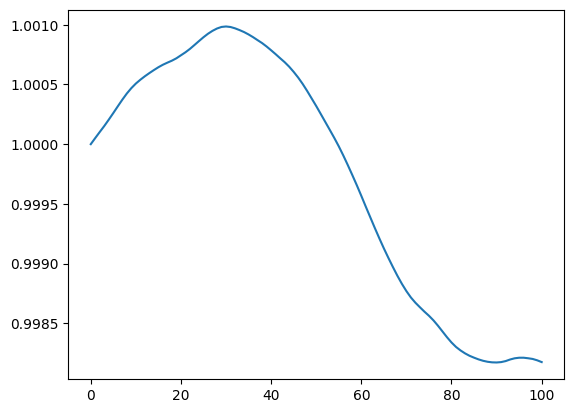

In [8]:
rad_ratio = mean_rad_bar_norm/mean_rad_dm_norm

plt.plot(time_steps,rad_ratio)


In [10]:
print(Vrad)

[[ 0.00528598  0.01226061 -0.00718405 ... -0.00713494  0.00878857
  -0.00861641]
 [ 0.00555314  0.01161669  0.00301559 ... -0.00730019  0.00809594
  -0.00862369]
 [ 0.00578508  0.01097854  0.01248138 ... -0.00746177  0.00740385
  -0.00862883]
 ...
 [ 0.00502092  0.00877962 -0.00874006 ...  0.00680864 -0.01247628
   0.0050783 ]
 [ 0.00526735  0.00816977 -0.0091296  ...  0.00663244 -0.01299672
   0.00524832]
 [ 0.00547926  0.00756444 -0.00952235 ...  0.00645323 -0.01346512
   0.00541392]]


TypeError: cannot use 'numpy.ndarray' as a dict key (unhashable type: 'numpy.ndarray')

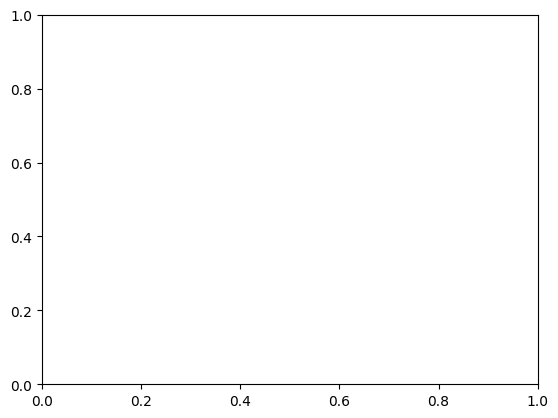

In [9]:
Vrad_dm = np.where(species == 0, Vrad, np.nan)
Vrad_bar = np.where(species == 1, Vrad, np.nan)

plt.imshow(rad_dm,Vrad_dm);

In [ ]:
# Create the animation
fig, ax = plt.subplots()
# Transpose the histogram so that the horizontal axis corresponds to R and vertical to Vrad
im = ax.imshow(all_histograms[0].T, origin='lower',
               extent=[bin_edges_R[0], bin_edges_R[-1], bin_edges_V[0], bin_edges_V[-1]],
               aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)

ax.set_xlabel("Radius")
ax.set_ylabel("Radial Velocity")
ax.set_title(f"Time Step: {time_steps[0]}")
fig.colorbar(im, ax=ax, label="Count")

def update(frame):
    im.set_data(all_histograms[frame].T)  # update image data
    ax.set_title(f"Time Step: {time_steps[frame]}")
    return im,

ani = FuncAnimation(fig, update, frames=len(time_steps), repeat=True, interval=200)

# Uncomment this line to show a static plot of the initial conditions
#plt.show()

plt.close(fig)

# Uncomment this line to save the animation as a GIF
# ani.save("../results/nsphere_phasespace_example.gif", writer="pillow", fps=10)

# For displaying in a Jupyter Notebook:
HTML(ani.to_jshtml())

In [ ]:
### THIS CELL MAKES AN ANIMATION OF THE EVOLUTION OF THE RADIUS-RADIAL VELOCITY PHASE SPACE



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.ndimage import gaussian_filter  # 2D smoothing filter
from IPython.display import HTML

# Define the path to the data files and the time steps
# Adjust the path to your data files as necessary
path_template = "../data/Rank_Mass_Rad_VRad_unsorted_t{timestep:05d}_1000000_10001_5.dat"
time_steps = range(0, 10, 1)  # Time steps from 0 to 99

# Define bin edges for radius (R) and radial velocity (Vrad)
# Adjust these ranges as needed for your data.
#bin_edges_R = np.arange(0, 300, 5)      # For radius: 0 to 300 in steps of 5 (original)
#bin_edges_V = np.arange(-300, 310, 10)     # For Vrad: -300 to 300 in steps of 10 (original)
bin_edges_R = np.arange(0, 10, 0.1)      # For radius: 0 to 10 in steps of 5 (altered)
bin_edges_V = np.arange(-50, 50, 0.5)     # For Vrad: -50 to 50 in steps of 10 (altered)

# Define the record dtype (as in nsphere.c; See project documentation.)
record_dtype = np.dtype([
    ('rank',  np.int32),
    ('mass',  np.float32),
    ('R',     np.float32),
    ('Vrad',  np.float32),
    ('PsiA',  np.float32),
    ('E',     np.float32),
    ('L',     np.float32)
])

# Storage for 2D histograms
all_histograms = []

# Loop over time steps and process each file
for time_step in time_steps:
    file_path = path_template.format(timestep=time_step)
    try:
        # Read the binary file
        alldata = np.fromfile(file_path, dtype=record_dtype)
        # Extract radius and radial velocity data
        data_R = alldata['R']
        data_Vrad = alldata['Vrad']/1.023e-3  # Convert to km/s
        
        if np.isnan(data_R).any() or np.isnan(data_Vrad).any():
            print(f"Warning: NaN values found in file at time step {time_step}")
        if not (np.isfinite(data_R).all() and np.isfinite(data_Vrad).all()):
            print(f"Warning: Non-finite values found in file at time step {time_step}")
        
        # Compute 2D histogram: counts for each (R, Vrad) bin
        hist, _, _ = np.histogram2d(data_R, data_Vrad, bins=[bin_edges_R, bin_edges_V])
        
        # Apply 2D Gaussian smoothing to reduce noise
        # Sigma value of 0.1 provides light smoothing while preserving structure
        smoothed_hist = gaussian_filter(hist, sigma=(0.1, 0.1))
        
        all_histograms.append(smoothed_hist)
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        # Append a zero histogram if file is missing or cannot be read
        all_histograms.append(np.zeros((len(bin_edges_R)-1, len(bin_edges_V)-1)))

# Convert list to numpy array for easier handling
all_histograms = np.array(all_histograms)
print("Histogram data shape:", all_histograms.shape)  # (time_steps, n_R_bins, n_V_bins)

# Determine common color scale for the animation
vmin = 0
vmax = np.max(all_histograms)  # Use the maximum value across all time steps

# Create the animation
fig, ax = plt.subplots()
# Transpose the histogram so that the horizontal axis corresponds to R and vertical to Vrad
im = ax.imshow(all_histograms[0].T, origin='lower',
               extent=[bin_edges_R[0], bin_edges_R[-1], bin_edges_V[0], bin_edges_V[-1]],
               aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)

ax.set_xlabel("Radius")
ax.set_ylabel("Radial Velocity")
ax.set_title(f"Time Step: {time_steps[0]}")
fig.colorbar(im, ax=ax, label="Count")

def update(frame):
    im.set_data(all_histograms[frame].T)  # update image data
    ax.set_title(f"Time Step: {time_steps[frame]}")
    return im,

ani = FuncAnimation(fig, update, frames=len(time_steps), repeat=True, interval=200)

# Uncomment this line to show a static plot of the initial conditions
#plt.show()

plt.close(fig)

# Uncomment this line to save the animation as a GIF
# ani.save("../results/nsphere_phasespace_example.gif", writer="pillow", fps=10)

# For displaying in a Jupyter Notebook:
HTML(ani.to_jshtml())